In [15]:
import pandas as pd
import numpy as np
import proplot as pplt
from scipy.stats import pearsonr

wind_df = pd.read_csv('./results/seasonal_max_wind_summary.csv')
solar_df = pd.read_csv('./results/seasonal_max_solar_summary.csv')

years = [2030, 2040, 2050]
climate_name = ['SSP245(c)', 'SSP585(c)', 'SSP245(h)','SSP585(h)']


/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() 

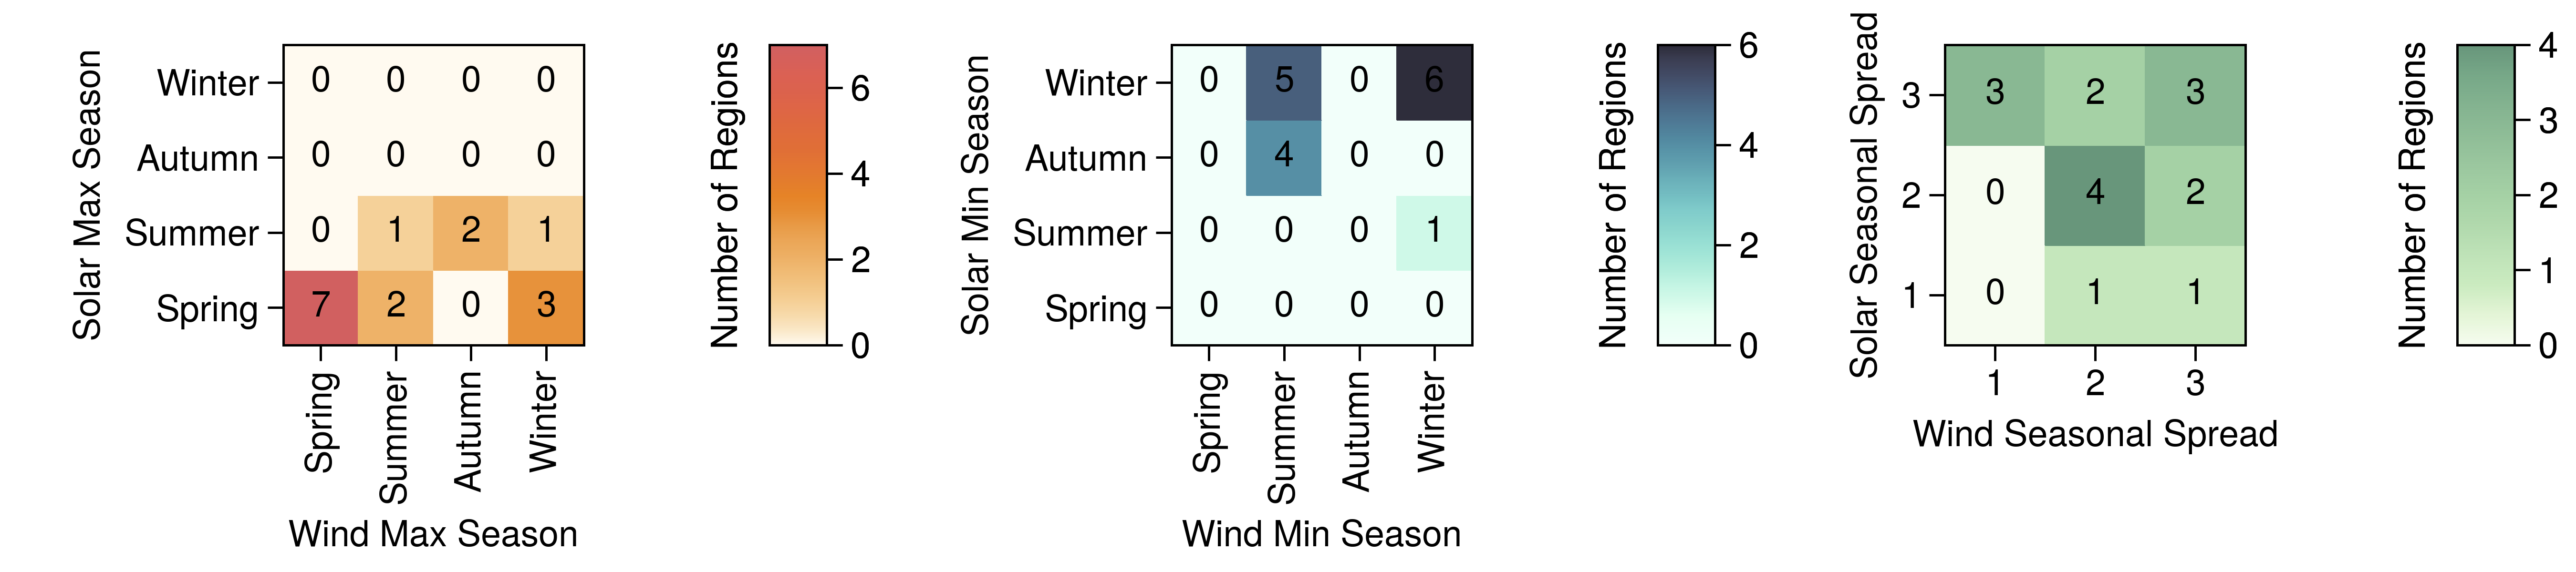

In [16]:
fig, axs = pplt.subplots(nrows=1, ncols=3, figsize=(9, 2), sharey=False, sharex=False,dpi=300)
fig.patch.set_facecolor('white')

cmap_up = pplt.Colormap('Reds_r', N=25)
cmap_down = pplt.Colormap('Blues_r', N=25)

ax = axs[0]
solar_2050 = solar_df[solar_df['year'] == 2050].set_index('region')
wind_2050 = wind_df[wind_df['year'] == 2050].set_index('region')

common_regions = solar_2050.index.intersection(wind_2050.index)
solar_seasons = solar_2050.loc[common_regions, 'max_season_idx']
wind_seasons = wind_2050.loc[common_regions, 'max_season_idx']

matrix = np.zeros((4, 4), dtype=int)  # rows: solar, cols: wind
for s, w in zip(solar_seasons, wind_seasons):
    if pd.notna(s) and pd.notna(w):
        s = int(s)
        w = int(w)
        if 0 <= s <= 3 and 0 <= w <= 3:
            matrix[s, w] += 1

seasons = ['Spring', 'Summer', 'Autumn', 'Winter']

m = ax.heatmap(matrix, cmap='Oranges2', colorbar='r', colorbar_kw={'pad': 2})
m.colorbar.set_label('Number of Regions', labelpad=-40)
ax.format(
    xlabel='Wind Max Season', ylabel='Solar Max Season',
    xticks=np.arange(4), xticklabels=seasons, yticks=np.arange(4), yticklabels=seasons, xrotation = 90)

for i in range(4):
    for j in range(4):
        ax.text(j, i, str(matrix[i, j]), ha='center', va='center', color='black')

ax = axs[1]
common_regions = solar_2050.index.intersection(wind_2050.index)
solar_seasons = solar_2050.loc[common_regions, 'min_season_idx']
wind_seasons = wind_2050.loc[common_regions, 'min_season_idx']

matrix = np.zeros((4, 4), dtype=int)  # rows: solar, cols: wind
for s, w in zip(solar_seasons, wind_seasons):
    if pd.notna(s) and pd.notna(w):
        s = int(s)
        w = int(w)
        if 0 <= s <= 3 and 0 <= w <= 3:
            matrix[s, w] += 1

seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
m = ax.heatmap(matrix, cmap='Blues6', colorbar='r', colorbar_kw={'pad': 2})
m.colorbar.set_label('Number of Regions', labelpad=-40)
ax.format(xlabel='Wind Min Season', ylabel='Solar Min Season',
    xticks=np.arange(4), xticklabels=seasons, yticks=np.arange(4), yticklabels=seasons, xrotation = 90)
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(matrix[i, j]), ha='center', va='center', color='black')

ax = axs[2]
solar_max = solar_2050['max_season_idx']
solar_min = solar_2050['min_season_idx']
wind_max = wind_2050['max_season_idx']
wind_min = wind_2050['min_season_idx']
solar_gap = ((solar_min-solar_max) % 4).replace(0, np.nan)
wind_gap = ((wind_min-wind_max) % 4).replace(0, np.nan)
common_regions = solar_gap.dropna().index.intersection(wind_gap.dropna().index)
solar_gap = solar_gap.loc[common_regions].astype(int)
wind_gap = wind_gap.loc[common_regions].astype(int)
matrix = np.zeros((3, 3), dtype=int)  # rows: solar gap, cols: wind gap
for s_gap, w_gap in zip(solar_gap, wind_gap):
    if 1 <= s_gap <= 3 and 1 <= w_gap <= 3:
        matrix[s_gap - 1, w_gap - 1] += 1
m = ax.heatmap(matrix, cmap='Greens7', colorbar='r', colorbar_kw={'pad': 2})
m.colorbar.set_label('Number of Regions', labelpad=-40)
ax.format(
    xlabel='Wind Seasonal Spread',
    ylabel='Solar Seasonal Spread',
    xticks=[0,1,2], xticklabels=['1', '2', '3'],
    yticks=[0,1,2], yticklabels=['1', '2', '3'],)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(matrix[i, j]), ha='center', va='center', color='black')
fig.savefig("./figs/national_season_trend.png", bbox_inches='tight', pad_inches=0)
